In [1]:
import sys, subprocess, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

from qiskit.circuit.library import ZZFeatureMap, TwoLocal, ZFeatureMap
from qiskit_aer.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms.classifiers import PegasosQSVC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.utils import algorithm_globals
from qiskit.primitives import Sampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [2]:
# ===== Parametry do łatwej zmiany =====
data_path   = "countsAll_fixed_07_07_23.csv"  # ścieżka do pliku z danymi
sep         = "\t"                            # separator (w Twoim pliku jest tab)
n_components_pca = 4                          # liczba komponentów PCA = liczba kubitów
test_size   = 0.20                            # ułamek danych do testu
random_state = 42                             # ziarno losowe
maxiter     = 10                             # iteracje optymalizatora
entanglement = "linear"                       # "linear" | "full" | lista par
reps_feature = 2                              # głębokość feature map
reps_ansatz  = 2  

In [3]:
df = pd.read_csv(data_path, sep=sep)
df = df.T

In [4]:
metadata = pd.read_csv("SampleInfo_fixed_08_07_23.csv", delimiter=";")
metadata = metadata.set_index("id")
metadata["label"] = metadata["GroupAlternative"].apply(
    lambda x: 0 if x == "Asymptomatic controls" else (1 if x == "Non-small-cell lung cancer" else np.nan)
)
metadata = metadata[metadata["RealLocation"] != "Institute 5"]
df = df.merge(metadata, left_index=True, right_index=True)

In [5]:
X = df.drop(columns=metadata.columns)
y = df["label"]

In [6]:
df_full_clean = df.dropna(subset=["label"])
X = df_full_clean.select_dtypes(include=[np.number]).drop(columns=["label"], errors="ignore")
y = df_full_clean["label"]
print("Rozkład klas po czyszczeniu:")
print(y.value_counts())

Rozkład klas po czyszczeniu:
label
1.0    355
0.0    354
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

In [8]:
# Najpierw wybierz 100 najlepiej różnicujących cech
selector = SelectKBest(score_func=f_classif, k=100)
X_selected = selector.fit_transform(X, y)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# Dopiero potem licz PCA na tych cechach
pca = PCA(n_components=n_components_pca, random_state=random_state)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)
print(f"Po PCA: X_train = {X_train_pca.shape}, X_test = {X_test_pca.shape}")

Po PCA: X_train = (567, 4), X_test = (142, 4)


In [9]:
X_train_qnn = X_train_pca
X_test_qnn = X_test_pca
y_train_qnn = y_train.to_numpy()
y_test_qnn = y_test.to_numpy()

In [10]:
t0 = time.time()
quantum_kernel = FidelityQuantumKernel()
pegasos_qsvc = PegasosQSVC(quantum_kernel=quantum_kernel)
pegasos_qsvc.fit(X_train_pca, y_train)
pegasos_qsvc.predict(X_test_pca)
y_pred = pegasos_qsvc.predict(X_test_pca)
acc_pegasos_qsvc = accuracy_score(y_test, y_pred)
pegasos_score = pegasos_qsvc.score(X_train_pca, y_train)
t_pegasos = time.time() - t0

In [11]:
print(f"PegasosQSVC classification test score: {pegasos_score:.4f}")
print(f"Accuracy: {acc_pegasos_qsvc:.4f}")
print(f"Computation time: {t_pegasos:4f}")

PegasosQSVC classification test score: 0.5009
Accuracy: 0.5000
Computation time: 11490.877288


In [12]:
y_pred_train = pegasos_qsvc.predict(X_train_pca)

# 1. Spłaszczenie predykcji
y_pred_train = y_pred_train.ravel()

# 2. Zamiana -1 na 0 (bo y_train ma tylko 0 i 1)
y_pred_train = np.where(y_pred_train == -1, 0, y_pred_train)

# 3. Konwersja do int
y_train = y_train.astype(int)
y_pred_train = y_pred_train.astype(int)

# 4. Obliczanie metryk
acc_train = accuracy_score(y_train, y_pred_train)
bal_acc_train = balanced_accuracy_score(y_train, y_pred_train)
sens_train = recall_score(y_train, y_pred_train, pos_label=1)  # TPR
spec_train = recall_score(y_train, y_pred_train, pos_label=0)  # TNR

try:
    y_score_train = pegasos_qsvc.predict_proba(X_train_pca)[:, 1]
    auc_train = roc_auc_score(y_train, y_score_train)
except Exception:
    auc_train = roc_auc_score(y_train, y_pred_train)

In [13]:
print(f"Accuracy: {acc_train:.3f}")
print(f"Balanced Accuracy: {bal_acc_train:.3f}")
print(f"Sensitivity (TPR): {sens_train:.3f}")
print(f"Specificity (TNR): {spec_train:.3f}")
print(f"ROC AUC:            {auc_train:.4f}")

Accuracy: 0.501
Balanced Accuracy: 0.500
Sensitivity (TPR): 1.000
Specificity (TNR): 0.000
ROC AUC:            0.2378


In [14]:
y_pred_test = pegasos_qsvc.predict(X_test_pca)

# 1. Spłaszczenie predykcji
y_pred_test = y_pred_test.ravel()

# 2. Zamiana -1 na 0 (bo y_train ma tylko 0 i 1)
y_pred_test = np.where(y_pred_test == -1, 0, y_pred_test)

# 3. Konwersja do int
y_test = y_test.astype(int)
y_pred_test = y_pred_test.astype(int)

# 4. Obliczanie metryk
acc_test = accuracy_score(y_test, y_pred_test)
bal_acc_test = balanced_accuracy_score(y_test, y_pred_test)
sens_test = recall_score(y_test, y_pred_test, pos_label=1)  # TPR
spec_test = recall_score(y_test, y_pred_test, pos_label=0)  # TNR

try:
    y_score_test = pegasos_qsvc.predict_proba(X_test_pca)[:, 1]
    auc_test = roc_auc_score(y_test, y_score_test)
except Exception:
    auc_test = roc_auc_score(y_test, y_pred_test)

In [15]:
print(f"Accuracy: {acc_test:.3f}")
print(f"Balanced Accuracy: {bal_acc_test:.3f}")
print(f"Sensitivity (TPR): {sens_test:.3f}")
print(f"Specificity (TNR): {spec_test:.3f}")
print(f"ROC AUC:            {auc_test:.4f}")

Accuracy: 0.500
Balanced Accuracy: 0.500
Sensitivity (TPR): 1.000
Specificity (TNR): 0.000
ROC AUC:            0.5402


In [16]:
print("\n=== Wyniki na TRAIN ===")
print(f"Accuracy:           {acc_train:.4f}")
print(f"Balanced accuracy:  {bal_acc_train:.4f}")
print(f"Sensitivity (TPR):  {sens_train:.4f}")
print(f"Specificity (TNR):  {spec_train:.4f}")
print(f"ROC AUC:            {auc_train:.4f}")
print("\n=== Wyniki na TEST ===")
print(f"Accuracy:           {acc_test:.4f}")
print(f"Balanced accuracy:  {bal_acc_test:.4f}")
print(f"Sensitivity (TPR):  {sens_test:.4f}")
print(f"Specificity (TNR):  {spec_test:.4f}")
print(f"ROC AUC:            {auc_test:.4f}")


=== Wyniki na TRAIN ===
Accuracy:           0.5009
Balanced accuracy:  0.5000
Sensitivity (TPR):  1.0000
Specificity (TNR):  0.0000
ROC AUC:            0.2378

=== Wyniki na TEST ===
Accuracy:           0.5000
Balanced accuracy:  0.5000
Sensitivity (TPR):  1.0000
Specificity (TNR):  0.0000
ROC AUC:            0.5402


In [17]:
print(f"Czas wykonania (s): {t_pegasos:.2f}")

Czas wykonania (s): 11490.88


In [18]:
# ===== ROC curve dla TRAIN =====
try:
    y_score_train = vqc.predict_proba(X_train_pca)[:, 1]
except Exception:
    # jeżeli nie ma predict_proba, bierzemy etykiety (to da schodkową krzywą)
    y_score_train = y_pred_train

fpr_train, tpr_train, _ = roc_curve(y_train, y_score_train)

# ===== ROC curve dla TEST =====
try:
    y_score_test = vqc.predict_proba(X_test_pca)[:, 1]
except Exception:
    y_score_test = y_pred_test

fpr_test, tpr_test, _ = roc_curve(y_test, y_score_test)

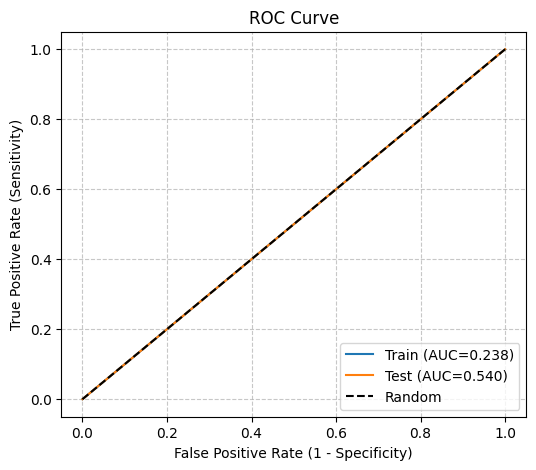

In [19]:
# ===== Rysowanie =====
plt.figure(figsize=(6, 5))
plt.plot(fpr_train, tpr_train, label=f"Train (AUC={auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test (AUC={auc_test:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()